#### PRACTICE QUESTION - 1

In [ ]:
# You are given a dataset of student marks.
# Use NumPy to generate 50 random marks between 40 and 100.
# Convert this into a Pandas DataFrame with a column named "Marks".
# Create another column "Result":
# "Pass" if marks ≥ 50
# "Fail" if marks < 50
# Using Seaborn, plot a count plot showing the number of Pass vs Fail students.
# Using Matplotlib, display a histogram of the marks distribution.


#solution 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

marks = np.random.randint(40, 101, 100)
print(marks)

print()

df = pd.DataFrame(marks, columns=["Marks"])

df["Result"] = df["Marks"].apply(lambda x: "Pass" if x>=50 else "Fail")

sns.countplot(x="Result", data=df)
plt.title("Pass vs Fail")
plt.show()

plt.hist(df["Marks"], bins=50)
plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

#### PRACTICE QUESTION - 2

[33 49 49 44 35 49 34 30 43 32 45 31 47 32 36 40 41 43 33 42 33 40 45 47
 46 31 43 32 46 30 31 41 50 46 34 38 32 39 46 46 33 44 36 48 45 45 44 35
 49 46 46 41 31 31 43 47 50 36 50 34 39 43 33 37 42 47 43 50 34 38 42 47
 50 36 47 38 34 45 49 49 37 36 36 43 38 49 42 41 30 47 33 49 34 40 48 42
 31 37 40 31]



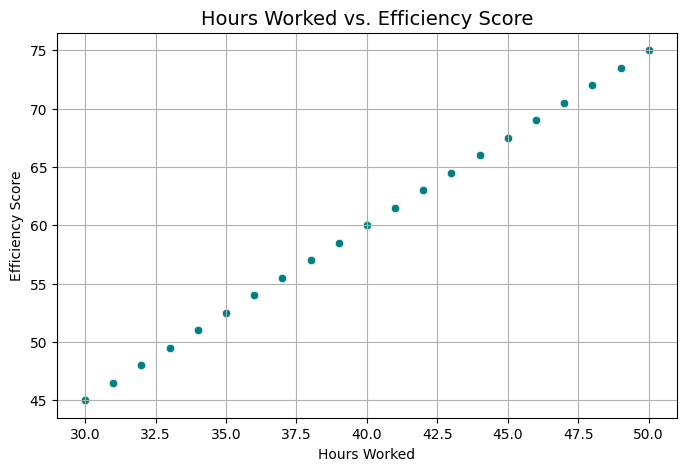

In [42]:
# The Challenge: Employee Performance Analysis
# The Question
# Generate Data: Create a NumPy array of 100 random integers representing "Hours Worked" (between 30 and 50).
# Process Data: Create a Pandas DataFrame with two columns: Hours_Worked and Efficiency_Score. The Efficiency_Score should be the Hours_Worked multiplied by a factor of 1.5.
# Visualize: Create a Scatter Plot using Seaborn to show the relationship between hours and efficiency, and add a custom title using Matplotlib

#solution 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hours = np.random.randint(30, 51, 100)

print(hours)

print()

df = pd.DataFrame({'Hours_Worked':hours, 'Efficiency_Score': hours * 1.5})

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Hours_Worked', y='Efficiency_Score', color='teal')

plt.title('Hours Worked vs. Efficiency Score', fontsize=14)
plt.xlabel('Hours Worked')
plt.ylabel('Efficiency Score')
plt.grid(True, linestyle='solid', alpha=1) 
plt.show()

#### PRACTICE QUESTION - 3

[ 46  99  12  42  31  21   3  22  47  54  25  82  35  67   5  94  12  99
  44  88  55  51  51   9  61  95  75  94  27  79  13  71  31  99  33  99
  58  51  66  25  64  70  17  77  81  14  12  30  11  53  60  68  90  99
  16  39  24  67  46  77  79  30  18  94  60  10  31   8  95  57  79  48
  96  30  87  93 100  22  13  52  85  44  78  38  57  78  26  43  50  89
  15  54  64  58  81  61  76  80  44  33]

Average Marks per Grade:
 Grades
A    96.142857
B    80.647059
C    59.200000
F    26.022727
Name: Marks, dtype: float64

Student Count per Grade:
 Grades
F    44
C    25
B    17
A    14
Name: count, dtype: int64


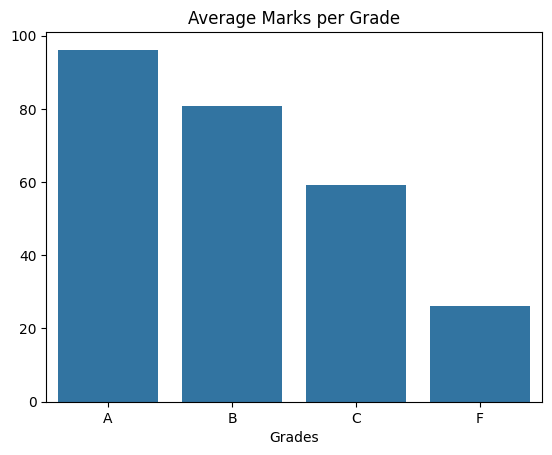

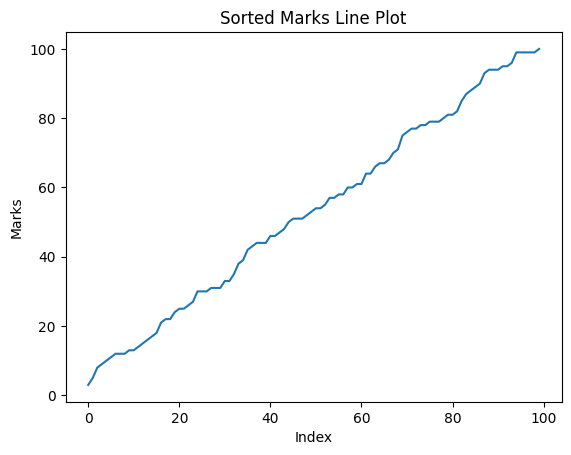

In [51]:
# You are given student marks again, but now think like a data analyst + problem solver:
# Use NumPy to generate 100 random marks between 0 and 100.
# Create a Pandas DataFrame with column "Marks".
# Create a "Grade" column using logic:
# 90–100 → "A"
# 75–89 → "B"
# 50–74 → "C"
# Below 50 → "F"
# Find:
# The average marks of each grade
# The number of students in each grade
# Using Seaborn, plot:
# A bar plot of average marks per grade
# Using Matplotlib, plot:
# A line plot of sorted marks (ascending)

#solution 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Marks = np.random.randint(0, 101, 100)
print(Marks)

print()

df = pd.DataFrame(Marks, columns=["Marks"])

def assign_grades(x):
    if x >= 90:
        return"A"
    elif x >= 75:
        return "B"
    elif x >= 50:
        return "C"
    else:
        return "F"

df["Grades"] = df["Marks"].apply(assign_grades)

avg_marks = df.groupby("Grades")["Marks"].mean()
count_students = df["Grades"].value_counts()

print("Average Marks per Grade:\n", avg_marks)
print("\nStudent Count per Grade:\n", count_students)

sns.barplot(x=avg_marks.index, y=avg_marks.values)
plt.title("Average Marks per Grade")
plt.show()

sorted_marks = df["Marks"].sort_values().reset_index(drop=True)

plt.plot(sorted_marks)
plt.title("Sorted Marks Line Plot")
plt.xlabel("Index")
plt.ylabel("Marks")
plt.show()

#### PRACTICE QUESTION - 4

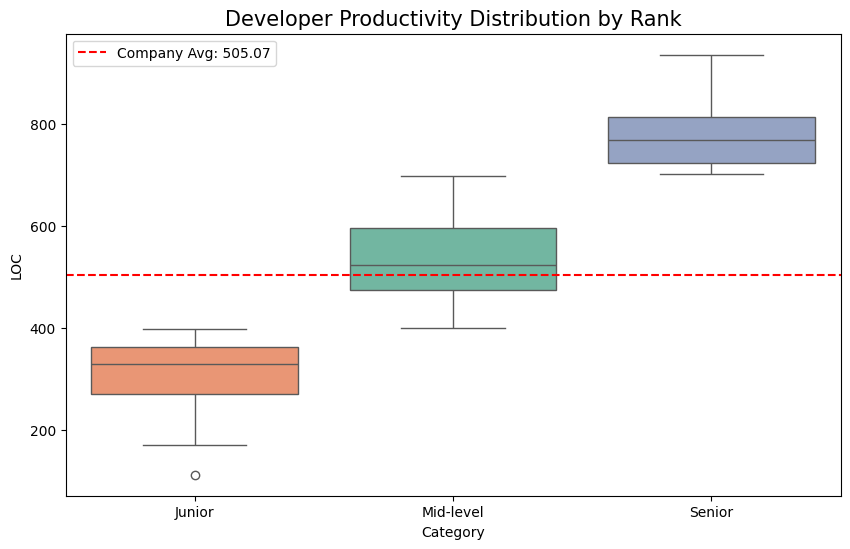

In [59]:
# The Challenge: Identifying Top-Performing Engineers
# The Question
# Generate Data: Create a NumPy array of 500 records representing "Lines of Code" (LOC) written by developers, following a normal distribution (mean=500, std=150).
# Logic (The "LeetCode" part):
# Create a Pandas DataFrame.
# Filter: Remove any "bugs" (records where LOC is less than 100).
# Transformation: Create a new column Category. If LOC > 700, label it "Senior"; between 400-700, "Mid-level"; below 400, "Junior".
# Visualisation:
# Use Seaborn to create a box plot showing the distribution of LOC across these three Category types.
# Use Matplotlib to annotate the plot with a horizontal line representing the average LOC across the entire company.

np.random.seed(43)
loc_data = np.random.normal(500, 150, 500)

df = pd.DataFrame({'LOC': loc_data})

df = df[df['LOC'] >= 100]

def classify_dev(loc):
    if loc > 700:
        return 'Senior'
    elif loc >= 400:
        return 'Mid-level'
    else:
        return 'Junior'
        
df['Category'] = df['LOC'].apply(classify_dev)    

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='Category', y='LOC', hue='Category', palette='Set2', order=['Junior', 'Mid-level', 'Senior'])

avg_loc = df['LOC'].mean()
plt.axhline(avg_loc, color='red', linestyle='--', label=f'Company Avg: {avg_loc:.2f}')

plt.title('Developer Productivity Distribution by Rank', fontsize=15)
plt.legend() 
plt.show()